In [31]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd

In [2]:
child_data_dir = "children_data"
adult_data_dir = "adult_data"

In [3]:
# get averages of any column across all participants in directory

def get_averages(data_directory, column_name, num_rows_to_process):
    files_in_dir = [f for f in os.listdir(data_directory) if f.endswith('.mat')]
    num_files = len(files_in_dir)

    S_matrix = np.full((num_rows_to_process, num_files), np.nan)

    for i, filename in enumerate(files_in_dir):
        file_path = os.path.join(data_directory, filename)
        mat_contents = sio.loadmat(file_path)
        data_column = mat_contents[column_name]

        squeezed_data = data_column.squeeze()
        processed_data = squeezed_data.flatten() if hasattr(squeezed_data, 'flatten') else np.array([squeezed_data])
        
        elements_to_extract = min(len(processed_data), num_rows_to_process)
        S_matrix[:elements_to_extract, i] = processed_data[:elements_to_extract]
            
    N = np.sum(~np.isnan(S_matrix), axis=1)
    std_dev = np.nanstd(S_matrix, axis=1, ddof=1)
    
    sem = np.zeros(num_rows_to_process)
    valid_n_for_sem = N > 1
    sem[valid_n_for_sem] = std_dev[valid_n_for_sem] / np.sqrt(N[valid_n_for_sem])

    S_matrix_for_mean = np.copy(S_matrix)
    S_matrix_for_mean[np.isnan(S_matrix_for_mean)] = 0 
    averages = np.mean(S_matrix_for_mean, axis=1)
            
    return averages, sem

In [4]:
num_rows_to_process = 70

child_avgs, child_sem = get_averages(child_data_dir, "EA", num_rows_to_process)
adult_avgs, adult_sem = get_averages(adult_data_dir, "EA", num_rows_to_process)

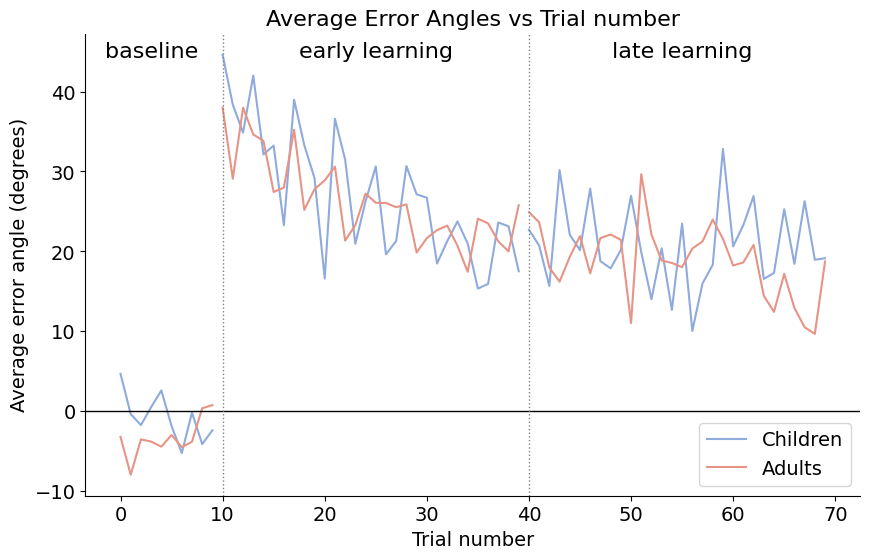

In [5]:
x_indices = np.arange(num_rows_to_process)

child_segment1_x = x_indices[0:10]
child_segment1_y = child_avgs[0:10]
child_segment2_x = x_indices[10:40]
child_segment2_y = child_avgs[10:40]
child_segment3_x = x_indices[40:70]
child_segment3_y = child_avgs[40:70]

adult_segment1_x = x_indices[0:10]
adult_segment1_y = adult_avgs[0:10]
adult_segment2_x = x_indices[10:40]
adult_segment2_y = adult_avgs[10:40]
adult_segment3_x = x_indices[40:70]
adult_segment3_y = adult_avgs[40:70]

child_plot_color = "#8faadc"
adult_plot_color = "#e79385"

plt.figure(figsize=(10, 6))

plt.plot(child_segment1_x, child_segment1_y, label='Children', color=child_plot_color) 
plt.plot(child_segment2_x, child_segment2_y, color=child_plot_color, label='_nolegend_')
plt.plot(child_segment3_x, child_segment3_y, color=child_plot_color, label='_nolegend_')

plt.plot(adult_segment1_x, adult_segment1_y, label='Adults', color=adult_plot_color) 
plt.plot(adult_segment3_x, adult_segment3_y, color=adult_plot_color, label='_nolegend_')
plt.plot(adult_segment2_x, adult_segment2_y, color=adult_plot_color, label='_nolegend_')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.axvline(x=10, color='gray', linestyle=':', linewidth=1)
plt.axvline(x=40, color='gray', linestyle=':', linewidth=1)

plt.text(3, plt.ylim()[1]*0.98, 'baseline', ha='center', va='top', fontsize=16)
plt.text(25, plt.ylim()[1]*0.98, 'early learning', ha='center', va='top', fontsize=16)
plt.text(55, plt.ylim()[1]*0.98, 'late learning', ha='center', va='top', fontsize=16)

plt.title('Average Error Angles vs Trial number', fontsize=16)
plt.xlabel('Trial number', fontsize=14)
plt.ylabel('Average error angle (degrees)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

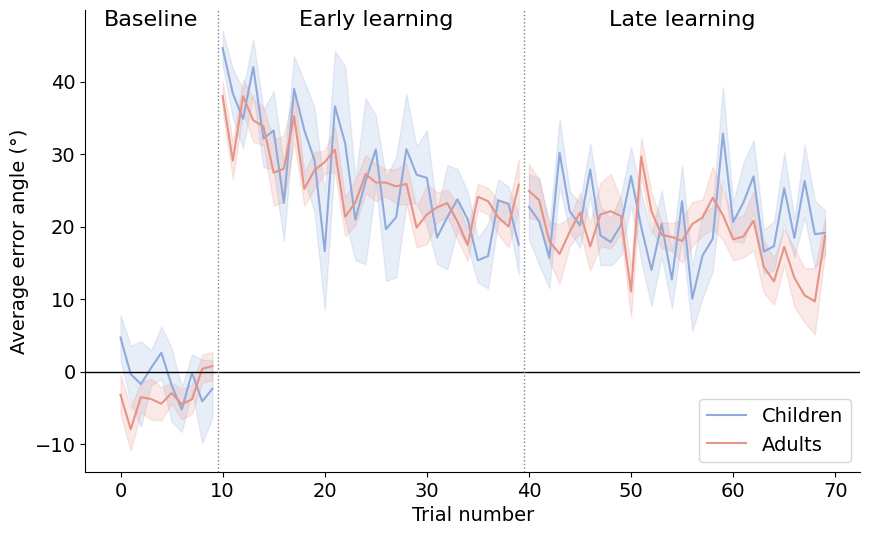

In [22]:
x_indices = np.arange(num_rows_to_process)

child_segment1_x = x_indices[0:10]
child_segment1_y = child_avgs[0:10]
child_sem_segment1 = child_sem[0:10]
child_segment2_x = x_indices[10:40]
child_segment2_y = child_avgs[10:40]
child_sem_segment2 = child_sem[10:40]
child_segment3_x = x_indices[40:70]
child_segment3_y = child_avgs[40:70]
child_sem_segment3 = child_sem[40:70]

adult_segment1_x = x_indices[0:10]
adult_segment1_y = adult_avgs[0:10]
adult_sem_segment1 = adult_sem[0:10]
adult_segment2_x = x_indices[10:40]
adult_segment2_y = adult_avgs[10:40]
adult_sem_segment2 = adult_sem[10:40]
adult_segment3_x = x_indices[40:70]
adult_segment3_y = adult_avgs[40:70]
adult_sem_segment3 = adult_sem[40:70]

child_plot_color = "#8faadc"
adult_plot_color = "#e79385"
alpha_level = 0.2

plt.figure(figsize=(10, 6))

plt.fill_between(child_segment1_x, child_segment1_y - child_sem_segment1, child_segment1_y + child_sem_segment1, color=child_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(child_segment1_x, child_segment1_y, label='Children', color=child_plot_color) 
plt.fill_between(child_segment2_x, child_segment2_y - child_sem_segment2, child_segment2_y + child_sem_segment2, color=child_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(child_segment2_x, child_segment2_y, color=child_plot_color, label='_nolegend_')
plt.fill_between(child_segment3_x, child_segment3_y - child_sem_segment3, child_segment3_y + child_sem_segment3, color=child_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(child_segment3_x, child_segment3_y, color=child_plot_color, label='_nolegend_')

plt.fill_between(adult_segment1_x, adult_segment1_y - adult_sem_segment1, adult_segment1_y + adult_sem_segment1, color=adult_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(adult_segment1_x, adult_segment1_y, label='Adults', color=adult_plot_color) 
plt.fill_between(adult_segment2_x, adult_segment2_y - adult_sem_segment2, adult_segment2_y + adult_sem_segment2, color=adult_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(adult_segment2_x, adult_segment2_y, color=adult_plot_color, label='_nolegend_')
plt.fill_between(adult_segment3_x, adult_segment3_y - adult_sem_segment3, adult_segment3_y + adult_sem_segment3, color=adult_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(adult_segment3_x, adult_segment3_y, color=adult_plot_color, label='_nolegend_')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.axvline(x=9.5, color='gray', linestyle=':', linewidth=1)
plt.axvline(x=39.5, color='gray', linestyle=':', linewidth=1)

plt.xlabel('Trial number', fontsize=14)
plt.ylabel('Average error angle (°)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

plt.text(3, plt.ylim()[1]*1, 'Baseline', ha='center', va='top', fontsize=16)
plt.text(25, plt.ylim()[1]*1, 'Early learning', ha='center', va='top', fontsize=16)
plt.text(55, plt.ylim()[1]*1, 'Late learning', ha='center', va='top', fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [7]:
child_meanMT, _ = get_averages(child_data_dir, "meanMT", 5)
adult_meanMT, _ = get_averages(adult_data_dir, "meanMT", 5)
child_meanMT, adult_meanMT

(array([0.96415253, 1.05556403, 1.06038086, 1.02744545, 1.07099568]),
 array([0.98099231, 1.13544401, 1.06668462, 0.98913846, 1.0928702 ]))

In [9]:
child_meanRT, _ = get_averages(child_data_dir, "meanRT", 5)
adult_meanRT, _ = get_averages(adult_data_dir, "meanRT", 5)
child_meanRT, adult_meanRT

(array([0.37469293, 0.3656945 , 0.36623159, 0.35691788, 0.35727118]),
 array([0.26470769, 0.25046506, 0.25462821, 0.26667949, 0.27585977]))

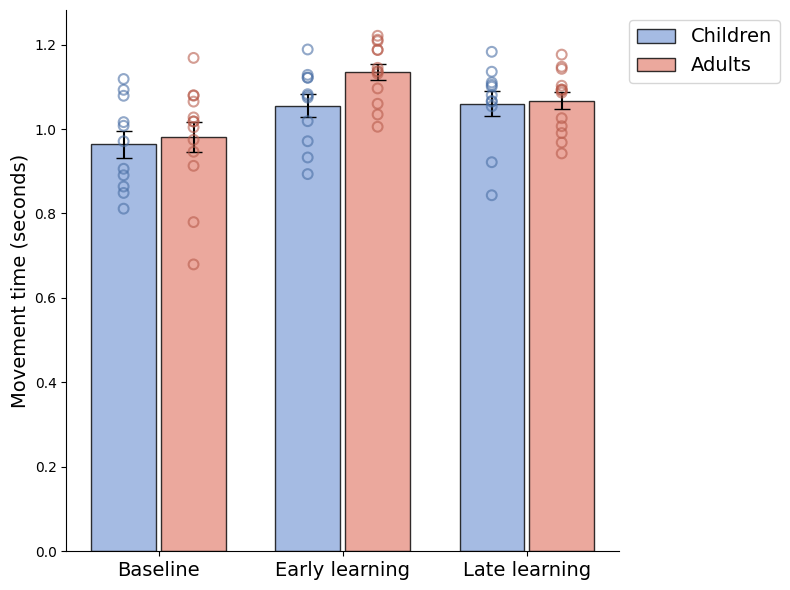

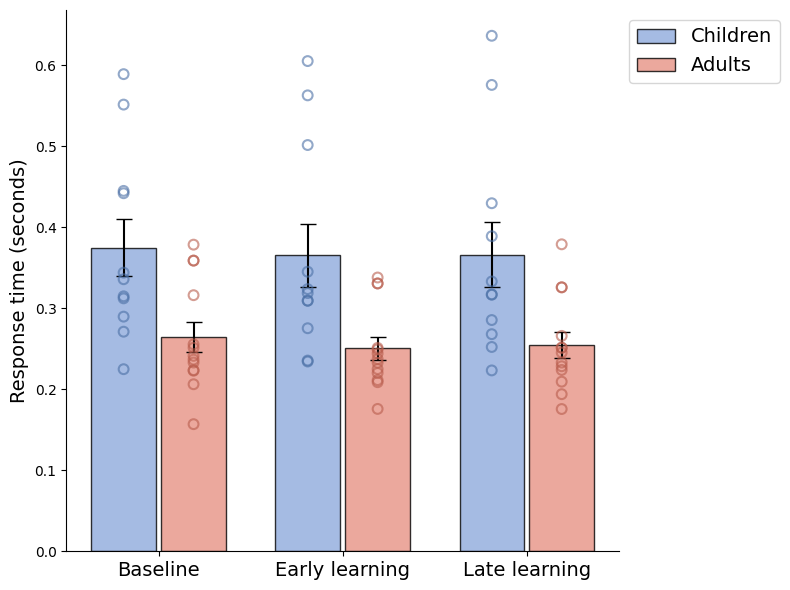

In [28]:
def get_all_participant_values(data_dir, column, phase_idx):
    values = []
    for filename in os.listdir(data_dir):
        if filename.endswith('.mat'):
            mat = sio.loadmat(os.path.join(data_dir, filename))
            col = mat[column].squeeze()
            # Defensive: handle both 1D and 2D
            if col.ndim > 0 and len(col) > phase_idx:
                values.append(col[phase_idx])
    return np.array(values)

def get_group_data(column, n):
    child_mean, child_sem = get_averages(child_data_dir, column, n)
    adult_mean, adult_sem = get_averages(adult_data_dir, column, n)
    return child_mean[:3], child_sem[:3], adult_mean[:3], adult_sem[:3]

labels = ["Baseline", "Early learning", "Late learning"]
phases = np.arange(len(labels))
width = 0.35
bar_gap = 0.03  

child_mt, child_mt_sem, adult_mt, adult_mt_sem = get_group_data("meanMT", 5)
fig, ax = plt.subplots(figsize=(8, 6))

bar1 = phases - width/2 - bar_gap/2
bar2 = phases + width/2 + bar_gap/2

bars_mt_child = ax.bar(bar1, child_mt, width, yerr=child_mt_sem, label="Children", color="#8faadc", capsize=6, edgecolor='black', alpha=0.8)
bars_mt_adult = ax.bar(bar2, adult_mt, width, yerr=adult_mt_sem, label="Adults", color="#e79385", capsize=6, edgecolor='black', alpha=0.8)

for i, phase in enumerate(phases):
    child_mt_points = get_all_participant_values(child_data_dir, "meanMT", i)
    adult_mt_points = get_all_participant_values(adult_data_dir, "meanMT", i)
    ax.scatter(np.full(len(child_mt_points), bar1[i]), child_mt_points, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.6, linewidths=1.5)
    ax.scatter(np.full(len(adult_mt_points), bar2[i]), adult_mt_points, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.6, linewidths=1.5)

ax.set_xticks(phases)
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel('Movement time (seconds)', fontsize=14)
ax.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

child_rt, child_rt_sem, adult_rt, adult_rt_sem = get_group_data("meanRT", 5)
fig, ax = plt.subplots(figsize=(8, 6))

bars_rt_child = ax.bar(bar1, child_rt, width, yerr=child_rt_sem, label="Children", color="#8faadc", capsize=6, edgecolor='black', alpha=0.8)
bars_rt_adult = ax.bar(bar2, adult_rt, width, yerr=adult_rt_sem, label="Adults", color="#e79385", capsize=6, edgecolor='black', alpha=0.8)

for i, phase in enumerate(phases):
    child_rt_points = get_all_participant_values(child_data_dir, "meanRT", i)
    adult_rt_points = get_all_participant_values(adult_data_dir, "meanRT", i)
    ax.scatter(np.full(len(child_rt_points), bar1[i]), child_rt_points, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.6, linewidths=1.5)
    ax.scatter(np.full(len(adult_rt_points), bar2[i]), adult_rt_points, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.6, linewidths=1.5)

ax.set_xticks(phases)
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel('Response time (seconds)', fontsize=14)
ax.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

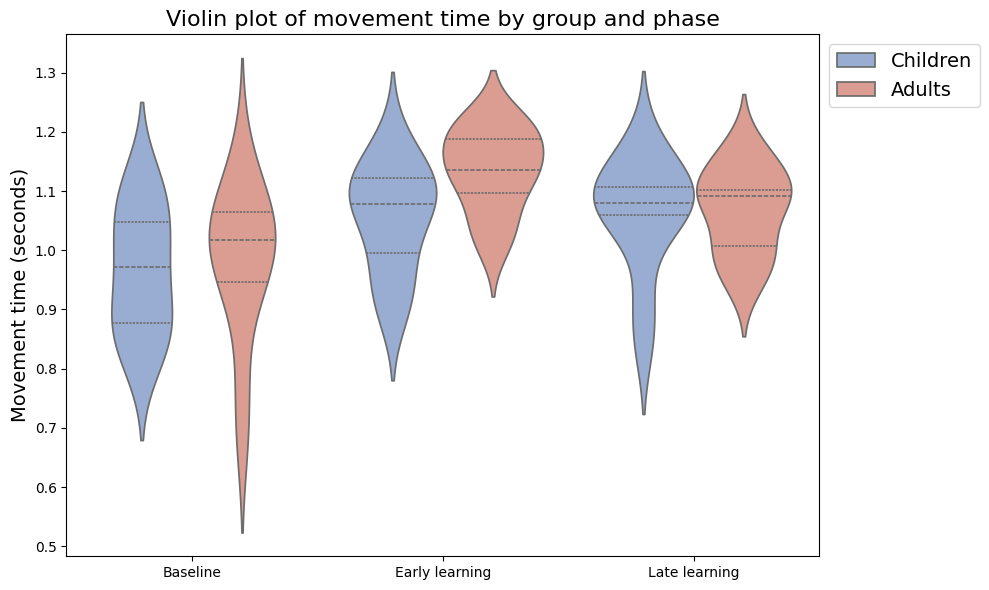

In [35]:
# Violin plot for meanMT (separate violins for each group)
phases = ["Baseline", "Early learning", "Late learning"]
child_mt_all = [get_all_participant_values(child_data_dir, "meanMT", i) for i in range(3)]
adult_mt_all = [get_all_participant_values(adult_data_dir, "meanMT", i) for i in range(3)]

mt_data = []
for i, phase in enumerate(phases):
    for v in child_mt_all[i]:
        mt_data.append({"Group": "Children", "Phase": phase, "Value": v})
    for v in adult_mt_all[i]:
        mt_data.append({"Group": "Adults", "Phase": phase, "Value": v})
mt_df = pd.DataFrame(mt_data)

plt.figure(figsize=(10,6))
sns.violinplot(x="Phase", y="Value", hue="Group", data=mt_df, split=False, inner="quartile", palette=["#8faadc", "#e79385"])
plt.ylabel("Movement time (seconds)", fontsize=14)
plt.xlabel("")
plt.title("Violin plot of movement time by group and phase", fontsize=16)
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

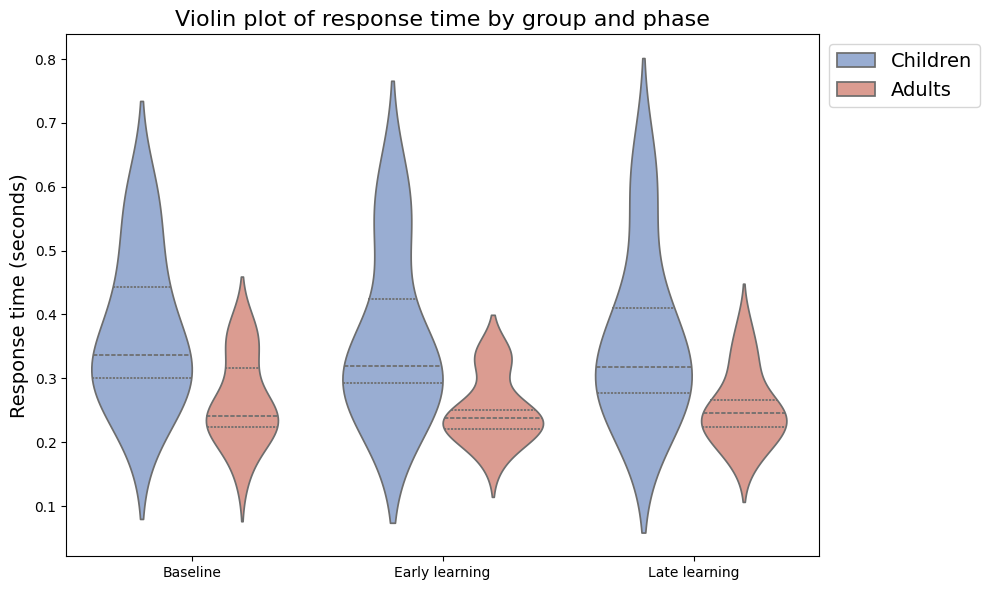

In [36]:
# Violin plot for meanRT (separate violins for each group)
child_rt_all = [get_all_participant_values(child_data_dir, "meanRT", i) for i in range(3)]
adult_rt_all = [get_all_participant_values(adult_data_dir, "meanRT", i) for i in range(3)]

rt_data = []
for i, phase in enumerate(phases):
    for v in child_rt_all[i]:
        rt_data.append({"Group": "Children", "Phase": phase, "Value": v})
    for v in adult_rt_all[i]:
        rt_data.append({"Group": "Adults", "Phase": phase, "Value": v})
rt_df = pd.DataFrame(rt_data)

plt.figure(figsize=(10,6))
sns.violinplot(x="Phase", y="Value", hue="Group", data=rt_df, split=False, inner="quartile", palette=["#8faadc", "#e79385"])
plt.ylabel("Response time (seconds)", fontsize=14)
plt.xlabel("")
plt.title("Violin plot of response time by group and phase", fontsize=16)
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

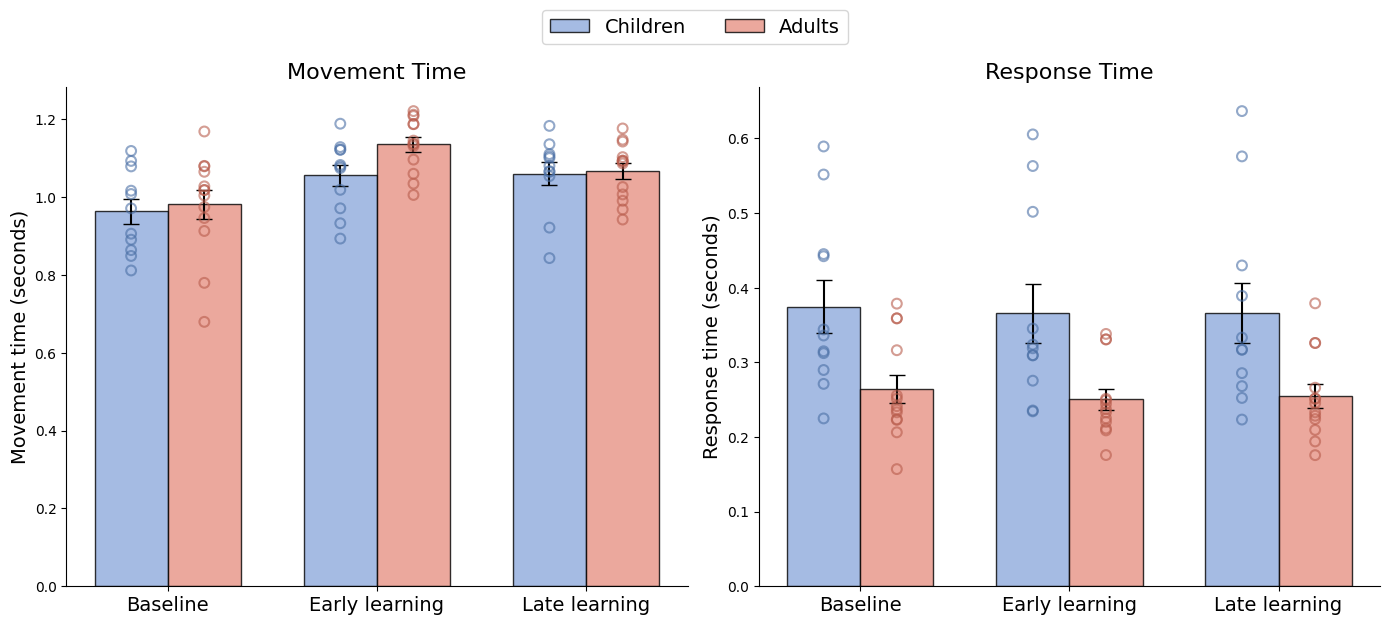

In [43]:
labels = ["Baseline", "Early learning", "Late learning"]
phases = np.arange(len(labels))
width = 0.35

child_mt, child_mt_sem, adult_mt, adult_mt_sem = get_group_data("meanMT", 5)
child_rt, child_rt_sem, adult_rt, adult_rt_sem = get_group_data("meanRT", 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Movement Time subplot
ax = axes[0]
bar1 = phases - width/2
bar2 = phases + width/2
bars_mt_child = ax.bar(bar1, child_mt, width, yerr=child_mt_sem, label="Children", color="#8faadc", capsize=6, edgecolor='black', alpha=0.8)
bars_mt_adult = ax.bar(bar2, adult_mt, width, yerr=adult_mt_sem, label="Adults", color="#e79385", capsize=6, edgecolor='black', alpha=0.8)
for i, phase in enumerate(phases):
    child_mt_points = get_all_participant_values(child_data_dir, "meanMT", i)
    adult_mt_points = get_all_participant_values(adult_data_dir, "meanMT", i)
    ax.scatter(np.full(len(child_mt_points), bar1[i]), child_mt_points, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.6, linewidths=1.5)
    ax.scatter(np.full(len(adult_mt_points), bar2[i]), adult_mt_points, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.6, linewidths=1.5)
ax.set_xticks(phases)
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel('Movement time (seconds)', fontsize=14)
ax.set_title('Movement Time', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Response Time subplot
ax = axes[1]
bar1 = phases - width/2
bar2 = phases + width/2
bars_rt_child = ax.bar(bar1, child_rt, width, yerr=child_rt_sem, label="Children", color="#8faadc", capsize=6, edgecolor='black', alpha=0.8)
bars_rt_adult = ax.bar(bar2, adult_rt, width, yerr=adult_rt_sem, label="Adults", color="#e79385", capsize=6, edgecolor='black', alpha=0.8)
for i, phase in enumerate(phases):
    child_rt_points = get_all_participant_values(child_data_dir, "meanRT", i)
    adult_rt_points = get_all_participant_values(adult_data_dir, "meanRT", i)
    ax.scatter(np.full(len(child_rt_points), bar1[i]), child_rt_points, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.6, linewidths=1.5)
    ax.scatter(np.full(len(adult_rt_points), bar2[i]), adult_rt_points, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.6, linewidths=1.5)
ax.set_xticks(phases)
ax.set_xticklabels(labels, fontsize=14)
ax.set_ylabel('Response time (seconds)', fontsize=14)
ax.set_title('Response Time', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Shared legend
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()